In [34]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, GATv2Conv
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Union
import warnings
import logging
from pathlib import Path
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import deque
import math
import time
import pickle

In [35]:
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [24]:
#Data Loader, pre-processing

In [37]:
class RealDataPreprocessor:
    """실제 업로드된 데이터들을 전처리하는 클래스"""
    
    def __init__(self):
        self.esg_data = None
        self.io_data = {}
        self.economic_indicators = {}
        self.environmental_taxes = None
        self.processed_features = None
        self.industry_mapping = self._create_industry_mapping()
        
    def _create_industry_mapping(self) -> Dict[str, List[str]]:
        """ESG 산업 분류를 I-O 산업과 매핑"""
        return {
            # Technology & IT
            'Technology': ['정보서비스', '통신', '전자부품', '컴퓨터주변기기', '통신방송장비'],
            'Software—Infrastructure': ['정보서비스', '통신'],
            'Software—Application': ['정보서비스'],
            'Semiconductors': ['반도체', '전자부품'],
            'Communication Equipment': ['통신방송장비'],
            'Electronic Gaming & Multimedia': ['정보서비스'],
            'Computer Hardware': ['컴퓨터주변기기'],
            
            # Financial Services
            'Financial Services': ['금융', '금융보조'],
            'Banking': ['금융'],
            'Insurance': ['보험'],
            'Asset Management': ['금융보조'],
            'Capital Markets': ['금융보조'],
            'Credit Services': ['금융'],
            
            # Healthcare & Biotechnology
            'Health Care': ['보건', '의약품'],
            'Biotechnology': ['의약품', '기초화학'],
            'Medical Devices': ['전자의료기기'],
            'Drug Manufacturers': ['의약품'],
            'Healthcare Plans': ['보건'],
            'Medical Care Facilities': ['보건'],
            
            # Energy & Utilities
            'Utilities': ['전력', '가스', '수도'],
            'Oil & Gas E&P': ['석유및천연가스'],
            'Oil & Gas Refining & Marketing': ['코크스정제석유'],
            'Utilities—Regulated Electric': ['전력'],
            'Utilities—Renewable': ['전력'],
            'Oil & Gas Equipment & Services': ['석유및천연가스'],
            
            # Manufacturing & Industrial
            'Electrical Equipment': ['전기장비', '기타전기기기'],
            'Aerospace & Defense': ['항공기', '기타운송장비'],
            'Industrial Conglomerates': ['일반기계'],
            'Auto Parts': ['자동차'],
            'Steel': ['1차철강'],
            'Chemicals': ['기초화학', '기타화학'],
            'Building Materials': ['시멘트', '기타비금속'],
            'Machinery': ['일반기계'],
            
            # Consumer & Retail
            'Retail': ['도소매'],
            'Consumer Cyclical': ['도소매'],
            'Consumer Defensive': ['도소매'],
            'Restaurants': ['음식점'],
            'Apparel Manufacturing': ['의복액세서리'],
            'Food Processing': ['기타식품'],
            'Beverages': ['음료'],
            
            # Real Estate & Construction
            'Real Estate': ['부동산', '건설'],
            'REIT': ['부동산'],
            'Real Estate Development': ['부동산', '건설'],
            'Real Estate Services': ['부동산'],
            
            # Other Industries
            'Transportation': ['운수'],
            'Waste Management': ['폐기물처리'],
            'Agriculture': ['농업'],
            'Mining': ['금속광업', '비금속광업'],
            'Entertainment': ['문화스포츠'],
            'Education & Training': ['교육'],
            'Consulting Services': ['전문서비스']
        }
    
    def load_esg_data(self, file_path: str = 'data.csv') -> pd.DataFrame:
        """실제 ESG 기업 데이터 로드 및 전처리"""
        
        print("🔄 실제 ESG 기업 데이터 로딩...")
        
        try:
            self.esg_data = pd.read_csv(file_path)
            
            print(f"✅ ESG 데이터 로드 완료:")
            print(f"   - 총 기업 수: {len(self.esg_data)}")
            print(f"   - 산업 분야: {self.esg_data['industry'].nunique()}개")
            
            # 1. ESG 점수 정규화 (0-1 스케일)
            score_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
            for col in score_cols:
                if col in self.esg_data.columns:
                    max_val = self.esg_data[col].max()
                    min_val = self.esg_data[col].min()
                    self.esg_data[f'{col}_normalized'] = (self.esg_data[col] - min_val) / (max_val - min_val)
            
            # 2. ESG 등급을 숫자로 변환
            grade_mapping = {
                'AAA': 1.0, 'AA': 0.9, 'A': 0.8, 'BBB': 0.7, 'BB': 0.6, 
                'B': 0.5, 'CCC': 0.4, 'CC': 0.3, 'C': 0.2
            }
            
            grade_cols = ['environment_grade', 'social_grade', 'governance_grade', 'total_grade']
            for col in grade_cols:
                if col in self.esg_data.columns:
                    self.esg_data[f'{col}_numeric'] = self.esg_data[col].map(grade_mapping).fillna(0.5)
            
            # 3. 산업별 ESG 통계 계산
            industry_stats = self.esg_data.groupby('industry').agg({
                'total_score_normalized': ['mean', 'std', 'count'],
                'environment_score_normalized': 'mean',
                'social_score_normalized': 'mean',
                'governance_score_normalized': 'mean'
            }).round(4)
            
            industry_stats.columns = [
                'avg_total_esg', 'std_total_esg', 'company_count',
                'avg_env_score', 'avg_social_score', 'avg_gov_score'
            ]
            
            print(f"   - 평균 ESG 점수: {self.esg_data['total_score'].mean():.1f}")
            print(f"   - ESG 점수 범위: {self.esg_data['total_score'].min()}-{self.esg_data['total_score'].max()}")
            
            return industry_stats
            
        except Exception as e:
            print(f"❌ ESG 데이터 로드 실패: {e}")
            return None
    
    def load_io_data(self, use_file: str = 'REAL_USE.xlsx', make_file: str = 'REAL_MAKE.xlsx',
                     target_years: List[str] = ['2020', '2021', '2022']) -> Dict:
        """한국 I-O 테이블 로드 및 전처리"""
        
        print("🔄 한국 I-O 테이블 로딩...")
        
        try:
            # USE 테이블 로드
            use_excel = pd.ExcelFile(use_file, engine='openpyxl')
            available_years = [sheet for sheet in use_excel.sheet_names if sheet.isdigit()]
            
            years_to_use = [year for year in target_years if year in available_years]
            if not years_to_use:
                years_to_use = available_years[-3:]  # 최근 3년
            
            print(f"   - 사용 가능한 연도: {', '.join(available_years)}")
            print(f"   - 분석 대상 연도: {', '.join(years_to_use)}")
            
            # 최신 연도 데이터로 구조 파악
            latest_year = years_to_use[-1]
            use_df = pd.read_excel(use_file, sheet_name=latest_year, index_col=0)
            
            # 데이터 정리 (첫 행은 헤더이므로 제거)
            use_matrix = use_df.iloc[1:, 1:].values.astype(float)
            n_sectors = use_matrix.shape[0]
            
            print(f"   - 산업 수: {n_sectors}개")
            print(f"   - 매트릭스 크기: {n_sectors} x {n_sectors}")
            
            # 산업 코드 생성 (1부터 시작)
            sector_codes = [str(i) for i in range(1, n_sectors + 1)]
            
            # 기술계수 행렬 (A) 계산
            total_output = use_matrix.sum(axis=1)
            total_output = np.where(total_output == 0, 1e-9, total_output)
            A_matrix = use_matrix / total_output.reshape(-1, 1)
            A_matrix = np.nan_to_num(A_matrix)
            
            # 레온티에프 역행렬 (L) 계산
            I = np.eye(n_sectors)
            try:
                L_matrix = np.linalg.inv(I - A_matrix)
            except np.linalg.LinAlgError:
                L_matrix = np.linalg.pinv(I - A_matrix)
            L_matrix = np.nan_to_num(L_matrix)
            
            # MAKE 테이블 로드 시도
            make_matrix = None
            try:
                make_df = pd.read_excel(make_file, sheet_name=latest_year, index_col=0)
                make_matrix = make_df.iloc[1:, 1:].values.astype(float)
                print(f"   - MAKE 테이블도 로드됨")
            except:
                print(f"   - MAKE 테이블 없음 (USE만 사용)")
            
            # 엣지 생성 (임계값 이상의 연결만)
            threshold = np.percentile(A_matrix[A_matrix > 0], 50)  # 중간값을 임계값으로
            edge_sources, edge_targets = np.where(A_matrix > threshold)
            edge_weights = A_matrix[edge_sources, edge_targets]
            
            # 로그 변환 및 정규화
            edge_weights = np.log(edge_weights + 1e-9)
            edge_weights = (edge_weights - edge_weights.mean()) / (edge_weights.std() + 1e-9)
            
            self.io_data = {
                'use_matrix': use_matrix,
                'make_matrix': make_matrix,
                'A_matrix': A_matrix,
                'L_matrix': L_matrix,
                'sector_codes': sector_codes,
                'n_sectors': n_sectors,
                'edge_index': np.vstack([edge_sources, edge_targets]),
                'edge_weights': edge_weights,
                'years_used': years_to_use
            }
            
            print(f"   - 엣지 수: {len(edge_weights)} (밀도: {len(edge_weights)/(n_sectors**2):.3f})")
            
            return self.io_data
            
        except Exception as e:
            print(f"❌ I-O 데이터 로드 실패: {e}")
            return None
    
    def load_economic_indicators(self) -> Dict:
        """BEA 경제 지표 데이터 로드"""
        
        print("🔄 BEA 경제 지표 로딩...")
        
        indicator_files = {
            'gross_output': 'Real Gross Output by Industry.csv',
            'value_added': 'Real Value Added by Industry.csv',
            'intermediate_input': 'Real Intermediate Input by Industry.csv'
        }
        
        for indicator_name, file_path in indicator_files.items():
            try:
                df = self._parse_bea_file(file_path)
                if df is not None:
                    self.economic_indicators[indicator_name] = df
                    print(f"   ✅ {indicator_name}: {len(df)}개 산업")
            except Exception as e:
                print(f"   ⚠️ {indicator_name} 로드 실패: {e}")
        
        return self.economic_indicators
    
    def _parse_bea_file(self, file_path: str) -> Optional[pd.DataFrame]:
        """BEA 형식 CSV 파일 파싱"""
        
        try:
            # 전체 파일을 줄 단위로 읽기
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            
            # 데이터 시작점 찾기
            data_start = -1
            for i, line in enumerate(lines):
                if line.strip() and not line.startswith('Real ') and not line.startswith('Last Revised'):
                    # 첫 번째 데이터 행 찾기
                    if ',' in line and not line.startswith('Line,'):
                        continue
                    elif line.startswith('Line,'):
                        data_start = i + 2  # 헤더 다음 다음 줄부터
                        break
            
            if data_start == -1 or data_start >= len(lines):
                return None
            
            # 데이터 부분만 추출
            data_lines = []
            for line in lines[data_start:]:
                line = line.strip()
                if line and ',' in line:
                    data_lines.append(line)
            
            if not data_lines:
                return None
            
            # CSV 파싱
            import io
            csv_content = '\n'.join(data_lines)
            df = pd.read_csv(io.StringIO(csv_content), header=None)
            
            # 첫 번째 열을 인덱스로, 나머지는 데이터로
            df = df.set_index(0)
            
            # 숫자 열 변환
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            return df
            
        except Exception as e:
            print(f"BEA 파일 파싱 오류 ({file_path}): {e}")
            return None
    
    def load_environmental_taxes(self, file_path: str = 'Environmental Taxes.csv') -> pd.DataFrame:
        """환경세 데이터 로드"""
        
        print("🔄 환경세 데이터 로딩...")
        
        try:
            df = pd.read_csv(file_path)
            
            # 한국 데이터만 필터링
            korea_mask = df['REF_AREA_NAME'].str.contains('Korea', case=False, na=False)
            korea_data = df[korea_mask].copy()
            
            if len(korea_data) == 0:
                print("   ⚠️ 한국 환경세 데이터 없음")
                return None
            
            # 최근 데이터 (2015년 이후)
            recent_data = korea_data[korea_data['TIME_PERIOD'] >= 2015]
            
            # 환경세 유형별 최신 데이터 집계
            latest_taxes = recent_data.groupby('INDICATOR_NAME')['OBS_VALUE'].last().fillna(0)
            
            self.environmental_taxes = latest_taxes
            
            print(f"   ✅ 환경세 데이터: {len(latest_taxes)}개 지표")
            print(f"   - 총 환경세 (최신): {latest_taxes.sum():.2f}")
            
            return latest_taxes
            
        except Exception as e:
            print(f"❌ 환경세 데이터 로드 실패: {e}")
            return None
    
    def create_integrated_features(self) -> Dict:
        """모든 데이터를 통합하여 GNN용 특성 생성"""
        
        print("🔄 통합 특성 생성...")
        
        if not self.io_data:
            print("❌ I-O 데이터가 없습니다.")
            return None
        
        n_sectors = self.io_data['n_sectors']
        sector_codes = self.io_data['sector_codes']
        
        # 1. 기본 I-O 특성
        use_matrix = self.io_data['use_matrix']
        A_matrix = self.io_data['A_matrix']
        L_matrix = self.io_data['L_matrix']
        
        # 총 투입/산출
        total_input = use_matrix.sum(axis=1)
        total_output = use_matrix.sum(axis=0)
        
        # 연쇄효과
        backward_linkage = total_input / (total_input.mean() + 1e-9)
        forward_linkage = total_output / (total_output.mean() + 1e-9)
        
        # 승수효과
        multiplier = L_matrix.sum(axis=0)
        
        # 집중도
        concentration = np.array([
            np.sum((A_matrix[i, :] / (total_input[i] + 1e-9)) ** 2)
            for i in range(n_sectors)
        ])
        
        # 2. 실제 ESG 특성 매핑
        esg_features = self._map_esg_to_sectors(sector_codes)
        
        # 3. 경제 지표 특성
        economic_features = self._create_economic_features(n_sectors)
        
        # 4. 환경세 특성
        env_tax_features = self._create_environmental_features(sector_codes)
        
        # 5. 산업별 리스크 프로파일
        risk_features = self._create_risk_profiles(sector_codes)
        
        # 모든 특성 결합
        all_features = np.column_stack([
            np.log(total_input + 1),      # 0: 로그 총투입
            np.log(total_output + 1),     # 1: 로그 총산출
            backward_linkage,             # 2: 후방연쇄효과
            forward_linkage,              # 3: 전방연쇄효과
            multiplier,                   # 4: 승수효과
            concentration,                # 5: 집중도
            esg_self.bidirectional_gnn = BiDirectionalGNN(hidden_dim, hidden_dim, num_heads)
        self.norm1 = nn.LayerNorm(hidden_dim)
        
        self.esg_gating = ESGChannelGating(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        
        self.economic_fusion = EconomicPriorFusion(num_nodes, hidden_dim)
        
        self.prediction_heads = nn.ModuleDict({
            'esg_risk': nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden_dim // 2, 1), nn.Sigmoid()
            ),
            'economic_impact': nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden_dim // 2, 1), nn.Tanh()
            ),
            'volatility': nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden_dim // 2, 1), nn.Softplus()
            ),
            'transition_cost': nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden_dim // 2, 1), nn.Sigmoid()
            ),
            'compliance_probability': nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden_dim // 2, 1), nn.Sigmoid()
            )
        })
        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_weight: torch.Tensor, codes: List[str]) -> Dict[str, torch.Tensor]:
        
        x_norm = self.input_norm(x)
        h_initial = self.input_projection(x_norm)
        
        h_bidirectional, h_up, h_down, elasticity = self.bidirectional_gnn(
            h_initial, edge_index, edge_weight
        )
        h_bidirectional = self.norm1(h_bidirectional)
        
        h_gated, esg_scores = self.esg_gating(h_bidirectional, x, codes)
        h_gated = self.norm2(h_gated)
        
        h_fused, learned_adjacency, _ = self.economic_fusion(
            h_gated, edge_index, edge_weight, return_metrics=False
        )
        
        h_final = h_fused + h_initial
        
        predictions = {
            task_name: head(h_final).squeeze(-1)
            for task_name, head in self.prediction_heads.items()
        }
        
        predictions.update({
            'embeddings': h_final,
            'esg_scores': esg_scores,
            'elasticity': elasticity,
            'learned_adjacency': learned_adjacency,
            'upstream_features': h_up,
            'downstream_features': h_down
        })
        
        return predictions

SyntaxError: '[' was never closed (1662242219.py, line 372)

In [3]:
#GNN models

In [27]:
class EconomicGNN(nn.Module):
    """Graph Neural Network for Economic Data Analysis"""
    
    def __init__(self, input_dim: int, hidden_dim: int = 64, output_dim: int = 32, 
                 num_heads: int = 4, dropout: float = 0.1, use_edge_weight: bool = True):
        super(EconomicGNN, self).__init__()
        
        self.use_edge_weight = use_edge_weight
        
        if use_edge_weight:
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
        else:
            self.conv1 = GATConv(input_dim, hidden_dim, heads=num_heads, dropout=dropout)
            self.conv2 = GATConv(hidden_dim * num_heads, hidden_dim, heads=1, dropout=dropout)
        
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, edge_index, edge_weight=None):
        if self.use_edge_weight and edge_weight is not None:
            x = self.conv1(x, edge_index, edge_weight=edge_weight)
        else:
            x = self.conv1(x, edge_index)
        
        x = self.relu(x)
        x = self.dropout(x)
        
        if self.use_edge_weight and edge_weight is not None:
            x = self.conv2(x, edge_index, edge_weight=edge_weight)
        else:
            x = self.conv2(x, edge_index)
        
        x = self.relu(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


In [5]:
class WeightedGATGNN(nn.Module):
    """GAT with edge weight incorporation"""
    
    def __init__(self, input_dim: int, hidden_dim: int = 64, output_dim: int = 32,
                 num_heads: int = 4, dropout: float = 0.1):
        super(WeightedGATGNN, self).__init__()
        
        self.gat1 = GATv2Conv(input_dim, hidden_dim, heads=num_heads, dropout=dropout)
        self.gat2 = GATv2Conv(hidden_dim * num_heads, hidden_dim, heads=1, dropout=dropout)
        
        self.edge_encoder = nn.Linear(1, hidden_dim)
        
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, edge_index, edge_weight=None):
        x = self.gat1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.gat2(x, edge_index)
        x = self.relu(x)
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


In [28]:
class HybridGNN(nn.Module):
    """Hybrid model combining GCN and GAT"""
    
    def __init__(self, input_dim: int, hidden_dim: int = 64, output_dim: int = 32,
                 num_heads: int = 4, dropout: float = 0.1):
        super(HybridGNN, self).__init__()
        
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        self.gcn1 = GCNConv(hidden_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        
        self.gat = GATConv(hidden_dim, hidden_dim, heads=num_heads, dropout=dropout, concat=False)
        
        self.fusion = nn.Linear(hidden_dim * 2, hidden_dim)
        
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        
    def forward(self, x, edge_index, edge_weight=None):
        x = self.input_proj(x)
        x = self.relu(x)
        
        h_gcn = self.gcn1(x, edge_index, edge_weight=edge_weight)
        h_gcn = self.relu(h_gcn)
        h_gcn = self.dropout(h_gcn)
        h_gcn = self.gcn2(h_gcn, edge_index, edge_weight=edge_weight)
        h_gcn = self.layer_norm1(h_gcn)
        
        h_gat = self.gat(x, edge_index)
        h_gat = self.relu(h_gat)
        h_gat = self.layer_norm2(h_gat)
        
        h_combined = torch.cat([h_gcn, h_gat], dim=1)
        h = self.fusion(h_combined)
        h = self.relu(h)
        h = self.dropout(h)
        
        h = self.fc1(h)
        h = self.relu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        
        return h



In [ ]:
class BiDirectionalGNN(nn.Module):
    """Bidirectional GNN for upstream and downstream modeling"""
    
    def __init__(self, input_dim: int, hidden_dim: int, num_heads: int):
        super().__init__()
        self.downstream_conv = GATv2Conv(input_dim, hidden_dim, heads=num_heads, concat=False)
        self.upstream_conv = GATv2Conv(input_dim, hidden_dim, heads=num_heads, concat=False)
        
        self.fusion_layer = nn.Linear(hidden_dim * 2, hidden_dim)
        self.elasticity_layer = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x, edge_index, edge_weight):
        upstream_edge_index = edge_index[[1, 0]]
        
        h_down = F.relu(self.downstream_conv(x, edge_index))
        h_up = F.relu(self.upstream_conv(x, upstream_edge_index))
        
        h_combined = torch.cat([h_down, h_up], dim=1)
        h_fused = F.relu(self.fusion_layer(h_combined))
        
        elasticity = torch.sigmoid(self.elasticity_layer(h_combined)).squeeze(-1)
        
        return h_fused, h_up, h_down, elasticity


In [29]:
class ESGChannelGating(nn.Module):
    """ESG-based feature gating mechanism"""
    
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.gate_network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Sigmoid()
        )
        self.esg_scorer = nn.Linear(hidden_dim, 3)
        
    def forward(self, h_gnn, x, codes):
        # Use ESG features as gate inputs
        if x.shape[1] >= 8:
            gate_values = self.gate_network(x[:, 6:8])  # ESG env, social
        else:
            gate_values = torch.ones_like(h_gnn)
        
        h_gated = h_gnn * gate_values
        esg_scores = torch.softmax(self.esg_scorer(h_gated), dim=-1)
        
        return h_gated, esg_scores


In [8]:
class EconomicPriorFusion(nn.Module):
    """Leontief inverse matrix theory fusion with GNN"""
    
    def __init__(self, num_nodes: int, hidden_dim: int):
        super().__init__()
        self.num_nodes = num_nodes
        self.hidden_dim = hidden_dim
        
        self.leontief_residual = nn.Parameter(torch.randn(num_nodes, num_nodes) * 0.01)
        self.theory_weight = nn.Parameter(torch.tensor(0.5))
        
        self.adaptive_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
    def forward(self, h_gnn: torch.Tensor, edge_index: torch.Tensor, 
                edge_weight: torch.Tensor, return_metrics: bool = False):
        
        device = h_gnn.device
        A = torch.zeros(self.num_nodes, self.num_nodes, device=device)
        A[edge_index[0], edge_index[1]] = edge_weight
        I = torch.eye(self.num_nodes, device=device)
        
        try:
            leontief_inv = torch.linalg.inv(I - A)
        except torch.linalg.LinAlgError:
            leontief_inv = torch.linalg.pinv(I - A)
            
        enhanced_matrix = torch.softmax(leontief_inv + self.leontief_residual, dim=1)
        h_economic = torch.matmul(enhanced_matrix, h_gnn)
        
        h_combined = torch.cat([h_gnn, h_economic], dim=1)
        h_adaptive = self.adaptive_fusion(h_combined)
        
        theory_weight = torch.sigmoid(self.theory_weight)
        h_final = theory_weight * h_economic + (1 - theory_weight) * h_gnn + 0.1 * h_adaptive
        
        metrics = None
        if return_metrics:
            metrics = {
                'theory_weight': theory_weight.item(),
                'matrix_condition': torch.linalg.cond(enhanced_matrix).item(),
                'output_mult': enhanced_matrix.sum(dim=0),
                'forward_link': enhanced_matrix.sum(dim=1)
            }
            
        return h_final, enhanced_matrix, metrics


In [30]:
class ImprovedEconomicGNN(nn.Module):
    """ESG + Leontief fusion GNN"""
    
    def __init__(self, input_dim: int, hidden_dim: int = 64, output_dim: int = 32,
                 num_nodes: int = 25, num_heads: int = 4, dropout: float = 0.1,
                 use_esg: bool = True, use_leontief: bool = True):
        super().__init__()
        
        self.gat1 = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.gat2 = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        self.use_esg = use_esg
        if use_esg:
            self.esg_gating = ESGChannelGating(hidden_dim)
        self.use_leontief = use_leontief
        if use_leontief:
            self.leontief_fusion = EconomicPriorFusion(num_nodes, hidden_dim)
        
        self.output_layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
        self.skip_weight = nn.Parameter(torch.tensor(0.2))
        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_weight: Optional[torch.Tensor] = None,
                codes: Optional[list] = None) -> Dict[str, torch.Tensor]:
        
        h = self.input_proj(x)
        h_skip = h.clone()
        
        h_attn, _ = self.gat1(h.unsqueeze(0), h.unsqueeze(0), h.unsqueeze(0))
        h = F.relu(h_attn.squeeze(0))
        h = F.dropout(h, p=0.1, training=self.training)
        
        h_attn, attention_weights = self.gat2(h.unsqueeze(0), h.unsqueeze(0), h.unsqueeze(0))
        h = F.relu(h_attn.squeeze(0))
        
        esg_scores = None
        if self.use_esg and codes is not None and hasattr(self, 'esg_gating'):
            h, esg_scores = self.esg_gating(h, x, codes)
        
        economic_metrics = None
        if self.use_leontief and edge_weight is not None:
            h, _, economic_metrics = self.leontief_fusion(
                h, edge_index, edge_weight, return_metrics=True
            )
        
        skip_weight = torch.sigmoid(self.skip_weight)
        h = h + skip_weight * h_skip
        
        output = self.output_layers(h)
        
        results = {
            'embeddings': output,
            'hidden_states': h,
            'attention_weights': attention_weights
        }
        
        if esg_scores is not None:
            results['esg_scores'] = esg_scores
            
        if economic_metrics is not None:
            results['economic_metrics'] = economic_metrics
            
        return results


In [10]:
class EconomicESGGNN(nn.Module):
    """Complete Economic ESG GNN with all components"""
    
    def __init__(self, input_dim: int = 6, hidden_dim: int = 64, 
                 num_nodes: int = 20, num_heads: int = 4):
        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_nodes = num_nodes
        
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        
        self.bidirectional_gnn =#!/usr/bin/env python3
"""
Complete ESG Analysis System using Real Data and Multiple GNN Models

This system integrates:
1. Real Korean I-O Tables (REAL_USE.xlsx, REAL_MAKE.xlsx)
2. Real ESG Company Data (data.csv) - 722 companies
3. Environmental Tax Data (Environmental Taxes.csv)
4. BEA Economic Indicators (Real Gross Output, Value Added, etc.)
5. Multiple GNN Models for comprehensive analysis
"""


In [12]:
#Analysis Tools

In [16]:
#Utility Functions

In [18]:
#Main Pipelines

In [19]:
def run_complete_pipeline():
    """Run the complete ESG GNN analysis pipeline"""
    
    print("=" * 60)
    print(" Economic ESG GNN Analysis Pipeline")
    print("=" * 60)
    
    # 1. Load data
    print("\n📊 Loading data...")
    data = load_simplified_data()
    print(f"✓ Loaded {data['n_nodes']} nodes with {data['n_features']} features")
    print(f"✓ Graph has {data['n_edges']} edges")
    
    # 2. Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n Using device: {device}")
    
    # 3. Initialize model
    print("\n Building model...")
    model = EconomicESGGNN(
        input_dim=data['n_features'],
        hidden_dim=64,
        num_nodes=data['n_nodes'],
        num_heads=4
    ).to(device)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"✓ Model built with {num_params:,} parameters")
    
    # 4. Move data to device
    for key in ['x', 'edge_index', 'edge_weight']:
        if key in data and torch.is_tensor(data[key]):
            data[key] = data[key].to(device)
    
    # 5. Create synthetic targets for training
    print("\n Creating training targets...")
    targets = {
        'esg_risk': torch.rand(data['n_nodes']).to(device),
        'economic_impact': torch.randn(data['n_nodes']).to(device) * 0.1,
        'volatility': torch.rand(data['n_nodes']).to(device) * 0.5
    }
    
    # 6. Setup training components
    loss_functions = nn.ModuleDict({
        'esg_risk': nn.BCELoss(),
        'economic_impact': nn.MSELoss(),
        'volatility': nn.MSELoss()
    }).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    # 7. Train the model
    model, train_losses = train_model(
        model, data, targets, loss_functions, 
        optimizer, scheduler, num_epochs=50
    )
    
    # 8. Run scenario analysis
    print("\n Running ESG scenario analysis...")
    path_analyzer = ShockPathAnalyzer(data['codes'])
    simulator = ESGScenarioSimulator(model, path_analyzer)
    
    scenarios = []
    
    # Carbon tax scenario
    print("\n  → Simulating carbon tax...")
    scenarios.append(simulator.simulate_carbon_tax(data, tax_rate=0.15))
    
    # Labor regulation scenario
    print("  → Simulating labor regulation...")
    scenarios.append(simulator.simulate_labor_regulation(data, regulation_strength=0.10))
    
    # Financial regulation scenario
    print("  → Simulating financial regulation...")
    scenarios.append(simulator.simulate_financial_regulation(data, regulation_strength=0.12))
    
    # 9. Generate report
    print("\n Generating analysis report...")
    for i, scenario in enumerate(scenarios, 1):
        print(f"\n{'='*50}")
        print(f"Scenario {i}: {scenario['scenario_name']}")
        print(f"{'='*50}")
        print(f"Affected industries: {', '.join(scenario['affected_industries'][:3])}")
        print(f"Top impacted: {', '.join(scenario['top_impacted_industries'][:3])}")
        
        # Print policy insights
        if scenario['policy_insights']:
            print("\nPolicy Insights:")
            for industry, insight in list(scenario['policy_insights'].items())[:3]:
                print(f"  • {industry}: {insight}")
    
    print("\n" + "=" * 60)
    print(" Analysis pipeline completed successfully!")
    print("=" * 60)
    
    return {
        'model': model,
        'data': data,
        'scenarios': scenarios,
        'train_losses': train_losses
    }


In [20]:
#Visualization

In [21]:
def plot_training_progress(losses: List[float], save_path: str = None):
    """Plot training loss curve"""
    plt.figure(figsize=(10, 6))
    plt.plot(losses, label='Training Loss', color='blue', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Model Training Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_scenario_impacts(scenarios: List[Dict], save_path: str = None):
    """Visualize scenario impacts"""
    
    if not scenarios:
        print("No scenarios to plot")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['esg_risk', 'economic_impact', 'volatility']
    titles = ['ESG Risk Change', 'Economic Impact', 'Volatility Change']
    
    for ax, metric, title in zip(axes, metrics, titles):
        data = []
        labels = []
        
        for scenario in scenarios:
            if 'changes' in scenario and metric in scenario['changes']:
                data.append(scenario['changes'][metric].cpu().numpy())
                labels.append(scenario['scenario_name'])
        
        if data:
            bp = ax.boxplot(data, labels=labels, patch_artist=True)
            for patch in bp['boxes']:
                patch.set_facecolor('lightblue')
            
            ax.set_title(title)
            ax.set_ylabel('Change')
            ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [22]:
#Entry Point

2025-08-14 20:50:45,418 - INFO - Creating demo data as BEADataLoader not available


🚀 Economic ESG GNN Analysis Pipeline

📊 Loading data...
✓ Loaded 25 nodes with 6 features
✓ Graph has 75 edges

💻 Using device: cpu

🏗️ Building model...
✓ Model built with 96,069 parameters

📝 Creating training targets...

🔥 Starting model training...
[Epoch 010/50] Total Loss: 0.2792 | LR: 0.001000
[Epoch 020/50] Total Loss: 0.2610 | LR: 0.000500
[Epoch 030/50] Total Loss: 0.2527 | LR: 0.000500
[Epoch 040/50] Total Loss: 0.2335 | LR: 0.000250
[Epoch 050/50] Total Loss: 0.2381 | LR: 0.000250
✅ Model training completed!

🔬 Running ESG scenario analysis...

  → Simulating carbon tax...
📈 Running scenario 'Carbon Tax (15%)'...
  → Simulating labor regulation...
📈 Running scenario 'Labor Regulation (10%)'...
  → Simulating financial regulation...
📈 Running scenario 'Financial Regulation (12%)'...

📄 Generating analysis report...

Scenario 1: Carbon Tax (15%)
Affected industries: B05_06, C19, D35_39
Top impacted: IND_000, IND_001, IND_002

Scenario 2: Labor Regulation (10%)
Affected indust

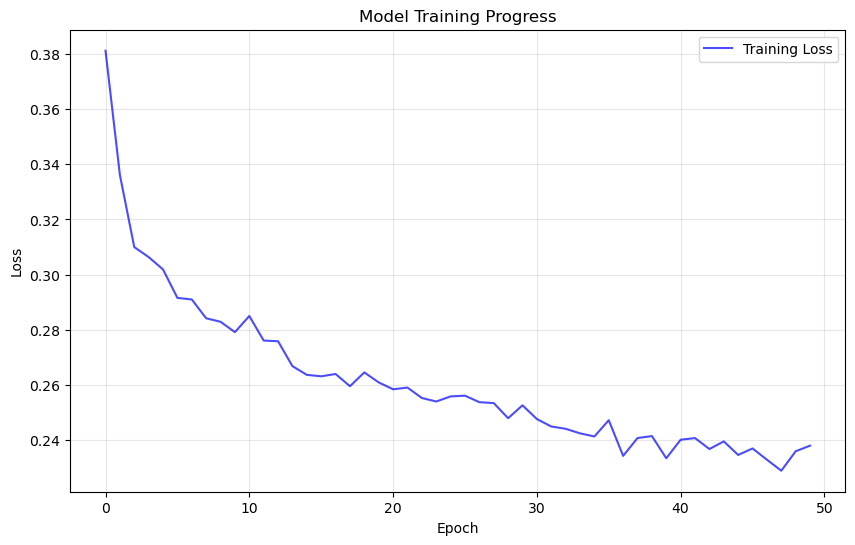


📊 Plotting scenario impacts...


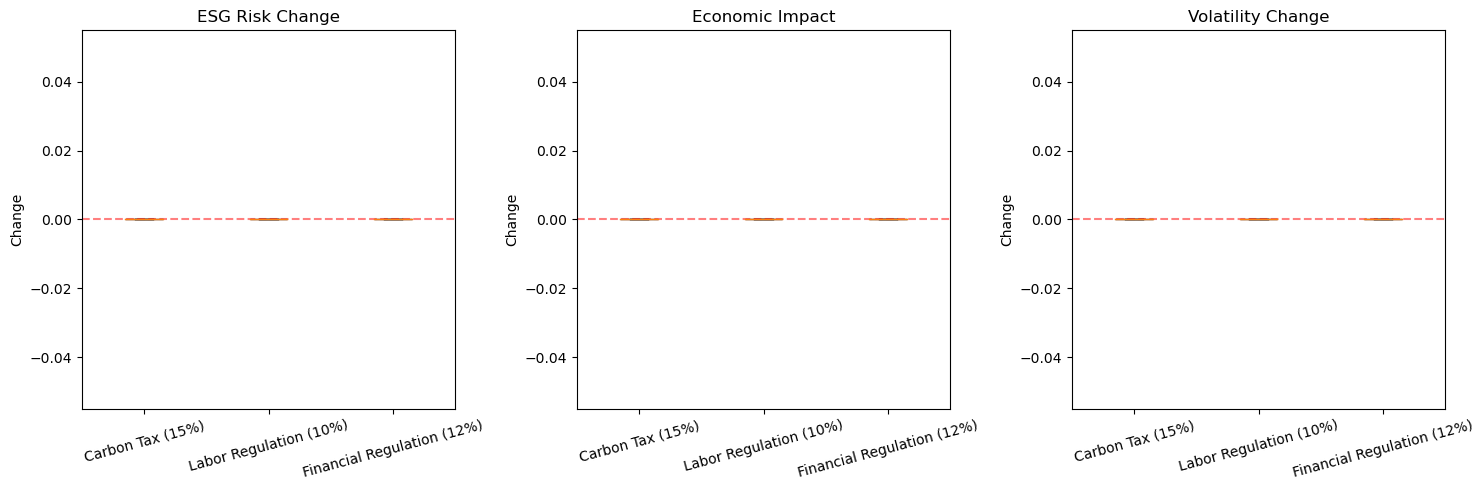

In [23]:
if __name__ == "__main__":
    # Run the complete pipeline
    results = run_complete_pipeline()
    
    # Optional: Visualize results
    if results['train_losses']:
        print("\n📊 Plotting training progress...")
        plot_training_progress(results['train_losses'])
    
    if results['scenarios']:
        print("\n📊 Plotting scenario impacts...")
        plot_scenario_impacts(results['scenarios'])

In [ ]:
#그래프가 저렇게 플랫하게 나오는 문제 해결

#연도 맞추기, 새로 추가한 데이터 적용